# CV CP Batch A3 Group 4

Necessary Imports

In [1]:
import numpy as np
import pandas as pd
import os
import csv
import cv2
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import Normalizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

Necessary folder paths

In [2]:
folder1=r"D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\Updated_Stray_Animal_Detection_59_66_70\Positive Images\Dog"
folder2=r"D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\Buffalo_Final\No_BG"
folder3=r"D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\Negative"

Preprocessing the images in the first folder and extracting features from it

In [3]:
i=0
for filename in os.listdir(folder1):
    #path
    path=os.path.join(folder1,filename)
    a=cv2.imread(path)
    
    #resize image
    resize=(100, 133)
    img=cv2.resize(a,resize)
    
    #gray image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    #initialise sift descriptor
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    #convert the descriptor array into a dataframe format
    out=pd.DataFrame(normalized)
    print("descriptor shape ",i," : ", out.shape)
    i=i+1
    
    #drop first coloumn as it's the no of feature detected. Not required.
    #append to the csv file
    csv_data=out.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Dog.csv', mode='a', header=False,index=False)

descriptor shape  0  :  (159, 128)
descriptor shape  1  :  (128, 128)
descriptor shape  2  :  (80, 128)
descriptor shape  3  :  (110, 128)
descriptor shape  4  :  (145, 128)
descriptor shape  5  :  (98, 128)
descriptor shape  6  :  (109, 128)
descriptor shape  7  :  (92, 128)
descriptor shape  8  :  (106, 128)
descriptor shape  9  :  (128, 128)
descriptor shape  10  :  (120, 128)
descriptor shape  11  :  (96, 128)
descriptor shape  12  :  (107, 128)
descriptor shape  13  :  (97, 128)
descriptor shape  14  :  (100, 128)
descriptor shape  15  :  (58, 128)
descriptor shape  16  :  (79, 128)
descriptor shape  17  :  (91, 128)
descriptor shape  18  :  (93, 128)
descriptor shape  19  :  (83, 128)
descriptor shape  20  :  (104, 128)
descriptor shape  21  :  (136, 128)
descriptor shape  22  :  (91, 128)
descriptor shape  23  :  (129, 128)
descriptor shape  24  :  (49, 128)
descriptor shape  25  :  (71, 128)
descriptor shape  26  :  (100, 128)
descriptor shape  27  :  (142, 128)
descriptor shap

descriptor shape  229  :  (101, 128)
descriptor shape  230  :  (125, 128)
descriptor shape  231  :  (106, 128)
descriptor shape  232  :  (68, 128)
descriptor shape  233  :  (137, 128)
descriptor shape  234  :  (160, 128)
descriptor shape  235  :  (169, 128)
descriptor shape  236  :  (55, 128)
descriptor shape  237  :  (131, 128)
descriptor shape  238  :  (73, 128)
descriptor shape  239  :  (133, 128)
descriptor shape  240  :  (126, 128)
descriptor shape  241  :  (102, 128)
descriptor shape  242  :  (152, 128)
descriptor shape  243  :  (79, 128)
descriptor shape  244  :  (102, 128)
descriptor shape  245  :  (127, 128)
descriptor shape  246  :  (66, 128)
descriptor shape  247  :  (127, 128)
descriptor shape  248  :  (130, 128)
descriptor shape  249  :  (121, 128)
descriptor shape  250  :  (160, 128)
descriptor shape  251  :  (30, 128)
descriptor shape  252  :  (32, 128)
descriptor shape  253  :  (133, 128)
descriptor shape  254  :  (84, 128)
descriptor shape  255  :  (97, 128)
descriptor

descriptor shape  455  :  (101, 128)
descriptor shape  456  :  (66, 128)
descriptor shape  457  :  (93, 128)
descriptor shape  458  :  (131, 128)
descriptor shape  459  :  (92, 128)
descriptor shape  460  :  (146, 128)
descriptor shape  461  :  (96, 128)
descriptor shape  462  :  (117, 128)
descriptor shape  463  :  (185, 128)
descriptor shape  464  :  (140, 128)
descriptor shape  465  :  (119, 128)
descriptor shape  466  :  (118, 128)
descriptor shape  467  :  (125, 128)
descriptor shape  468  :  (132, 128)
descriptor shape  469  :  (123, 128)
descriptor shape  470  :  (41, 128)
descriptor shape  471  :  (166, 128)
descriptor shape  472  :  (125, 128)
descriptor shape  473  :  (128, 128)
descriptor shape  474  :  (54, 128)
descriptor shape  475  :  (139, 128)
descriptor shape  476  :  (119, 128)
descriptor shape  477  :  (150, 128)
descriptor shape  478  :  (110, 128)
descriptor shape  479  :  (79, 128)
descriptor shape  480  :  (142, 128)
descriptor shape  481  :  (103, 128)
descript

descriptor shape  683  :  (72, 128)
descriptor shape  684  :  (169, 128)
descriptor shape  685  :  (112, 128)
descriptor shape  686  :  (179, 128)
descriptor shape  687  :  (230, 128)
descriptor shape  688  :  (148, 128)
descriptor shape  689  :  (94, 128)
descriptor shape  690  :  (67, 128)
descriptor shape  691  :  (70, 128)
descriptor shape  692  :  (100, 128)
descriptor shape  693  :  (107, 128)
descriptor shape  694  :  (169, 128)
descriptor shape  695  :  (61, 128)
descriptor shape  696  :  (129, 128)
descriptor shape  697  :  (55, 128)
descriptor shape  698  :  (172, 128)
descriptor shape  699  :  (123, 128)
descriptor shape  700  :  (76, 128)
descriptor shape  701  :  (100, 128)
descriptor shape  702  :  (60, 128)
descriptor shape  703  :  (131, 128)
descriptor shape  704  :  (128, 128)
descriptor shape  705  :  (176, 128)
descriptor shape  706  :  (186, 128)
descriptor shape  707  :  (114, 128)
descriptor shape  708  :  (158, 128)
descriptor shape  709  :  (69, 128)
descriptor

descriptor shape  909  :  (109, 128)
descriptor shape  910  :  (62, 128)
descriptor shape  911  :  (87, 128)
descriptor shape  912  :  (132, 128)
descriptor shape  913  :  (60, 128)
descriptor shape  914  :  (126, 128)
descriptor shape  915  :  (99, 128)
descriptor shape  916  :  (127, 128)
descriptor shape  917  :  (160, 128)
descriptor shape  918  :  (94, 128)
descriptor shape  919  :  (95, 128)
descriptor shape  920  :  (139, 128)
descriptor shape  921  :  (143, 128)
descriptor shape  922  :  (57, 128)
descriptor shape  923  :  (71, 128)
descriptor shape  924  :  (74, 128)
descriptor shape  925  :  (83, 128)
descriptor shape  926  :  (70, 128)
descriptor shape  927  :  (57, 128)
descriptor shape  928  :  (162, 128)
descriptor shape  929  :  (81, 128)
descriptor shape  930  :  (136, 128)
descriptor shape  931  :  (179, 128)
descriptor shape  932  :  (76, 128)
descriptor shape  933  :  (118, 128)
descriptor shape  934  :  (52, 128)
descriptor shape  935  :  (129, 128)
descriptor shape

...

descriptor shape  2013  :  (105, 128)
descriptor shape  2014  :  (135, 128)
descriptor shape  2015  :  (121, 128)
descriptor shape  2016  :  (98, 128)
descriptor shape  2017  :  (112, 128)
descriptor shape  2018  :  (84, 128)
descriptor shape  2019  :  (90, 128)
descriptor shape  2020  :  (97, 128)
descriptor shape  2021  :  (215, 128)
descriptor shape  2022  :  (142, 128)
descriptor shape  2023  :  (100, 128)
descriptor shape  2024  :  (84, 128)
descriptor shape  2025  :  (78, 128)
descriptor shape  2026  :  (126, 128)
descriptor shape  2027  :  (119, 128)
descriptor shape  2028  :  (150, 128)
descriptor shape  2029  :  (63, 128)
descriptor shape  2030  :  (76, 128)
descriptor shape  2031  :  (121, 128)
descriptor shape  2032  :  (158, 128)
descriptor shape  2033  :  (66, 128)
descriptor shape  2034  :  (61, 128)
descriptor shape  2035  :  (134, 128)
descriptor shape  2036  :  (108, 128)
descriptor shape  2037  :  (105, 128)
descriptor shape  2038  :  (83, 128)
descriptor shape  2039 

descriptor shape  2235  :  (38, 128)
descriptor shape  2236  :  (115, 128)
descriptor shape  2237  :  (99, 128)
descriptor shape  2238  :  (163, 128)
descriptor shape  2239  :  (89, 128)
descriptor shape  2240  :  (76, 128)
descriptor shape  2241  :  (83, 128)
descriptor shape  2242  :  (116, 128)
descriptor shape  2243  :  (88, 128)
descriptor shape  2244  :  (80, 128)
descriptor shape  2245  :  (104, 128)
descriptor shape  2246  :  (102, 128)
descriptor shape  2247  :  (132, 128)
descriptor shape  2248  :  (132, 128)
descriptor shape  2249  :  (168, 128)
descriptor shape  2250  :  (116, 128)
descriptor shape  2251  :  (104, 128)
descriptor shape  2252  :  (78, 128)
descriptor shape  2253  :  (140, 128)
descriptor shape  2254  :  (138, 128)
descriptor shape  2255  :  (176, 128)
descriptor shape  2256  :  (161, 128)
descriptor shape  2257  :  (102, 128)
descriptor shape  2258  :  (141, 128)
descriptor shape  2259  :  (132, 128)
descriptor shape  2260  :  (134, 128)
descriptor shape  22

descriptor shape  2457  :  (110, 128)
descriptor shape  2458  :  (92, 128)
descriptor shape  2459  :  (102, 128)
descriptor shape  2460  :  (135, 128)
descriptor shape  2461  :  (120, 128)
descriptor shape  2462  :  (108, 128)
descriptor shape  2463  :  (73, 128)
descriptor shape  2464  :  (116, 128)
descriptor shape  2465  :  (106, 128)
descriptor shape  2466  :  (107, 128)
descriptor shape  2467  :  (62, 128)
descriptor shape  2468  :  (133, 128)
descriptor shape  2469  :  (79, 128)
descriptor shape  2470  :  (102, 128)
descriptor shape  2471  :  (128, 128)
descriptor shape  2472  :  (101, 128)
descriptor shape  2473  :  (175, 128)
descriptor shape  2474  :  (71, 128)
descriptor shape  2475  :  (100, 128)
descriptor shape  2476  :  (146, 128)
descriptor shape  2477  :  (87, 128)
descriptor shape  2478  :  (90, 128)
descriptor shape  2479  :  (58, 128)
descriptor shape  2480  :  (136, 128)
descriptor shape  2481  :  (115, 128)
descriptor shape  2482  :  (127, 128)
descriptor shape  24

descriptor shape  2678  :  (48, 128)
descriptor shape  2679  :  (62, 128)
descriptor shape  2680  :  (139, 128)
descriptor shape  2681  :  (164, 128)
descriptor shape  2682  :  (117, 128)
descriptor shape  2683  :  (140, 128)
descriptor shape  2684  :  (140, 128)
descriptor shape  2685  :  (96, 128)
descriptor shape  2686  :  (175, 128)
descriptor shape  2687  :  (125, 128)
descriptor shape  2688  :  (91, 128)
descriptor shape  2689  :  (102, 128)
descriptor shape  2690  :  (82, 128)
descriptor shape  2691  :  (141, 128)
descriptor shape  2692  :  (147, 128)
descriptor shape  2693  :  (87, 128)
descriptor shape  2694  :  (129, 128)
descriptor shape  2695  :  (133, 128)
descriptor shape  2696  :  (82, 128)
descriptor shape  2697  :  (130, 128)
descriptor shape  2698  :  (106, 128)
descriptor shape  2699  :  (156, 128)
descriptor shape  2700  :  (104, 128)
descriptor shape  2701  :  (86, 128)
descriptor shape  2702  :  (123, 128)
descriptor shape  2703  :  (86, 128)
descriptor shape  270

descriptor shape  2903  :  (169, 128)
descriptor shape  2904  :  (58, 128)
descriptor shape  2905  :  (101, 128)
descriptor shape  2906  :  (118, 128)
descriptor shape  2907  :  (71, 128)
descriptor shape  2908  :  (163, 128)
descriptor shape  2909  :  (105, 128)
descriptor shape  2910  :  (109, 128)
descriptor shape  2911  :  (126, 128)
descriptor shape  2912  :  (75, 128)
descriptor shape  2913  :  (114, 128)
descriptor shape  2914  :  (80, 128)
descriptor shape  2915  :  (64, 128)
descriptor shape  2916  :  (88, 128)
descriptor shape  2917  :  (136, 128)
descriptor shape  2918  :  (73, 128)
descriptor shape  2919  :  (95, 128)
descriptor shape  2920  :  (177, 128)
descriptor shape  2921  :  (59, 128)
descriptor shape  2922  :  (69, 128)
descriptor shape  2923  :  (109, 128)
descriptor shape  2924  :  (188, 128)
descriptor shape  2925  :  (108, 128)
descriptor shape  2926  :  (138, 128)
descriptor shape  2927  :  (111, 128)
descriptor shape  2928  :  (237, 128)
descriptor shape  2929

Reading the csv files of extracted features

In [4]:
data1 = pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Dog.csv',header=None,dtype='float64')
#MemoryError: Unable to allocate 166. MiB for an array with shape (128, 169606) and data type float64,
#Double-precision floating-point format

data1=data1.astype(np.float64) 
#as unit8 contain 1 byte(8bit) and ranges from 0 to 255
data1

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.021509,0.007822,0.025420,0.097770,0.050841,0.033242,0.009777,0.019554,0.089949,0.011732,...,0.000000,0.009777,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076115,0.027323,...,0.000000,0.033178,0.007807,0.009758,0.013662,0.265426,0.121003,0.000000,0.000000,0.000000
2,0.001951,0.001951,0.013659,0.160008,0.089760,0.046832,0.021464,0.003903,0.015611,0.126835,...,0.009757,0.031221,0.000000,0.001951,0.228304,0.220498,0.017562,0.001951,0.005854,0.003903
3,0.023433,0.027339,0.165986,0.103497,0.017575,0.019528,0.046867,0.037103,0.005858,0.085922,...,0.054678,0.080064,0.000000,0.001953,0.013669,0.035150,0.070300,0.005858,0.000000,0.000000
4,0.089806,0.019523,0.007809,0.021475,0.068330,0.023428,0.013666,0.033189,0.076140,0.046855,...,0.099567,0.050760,0.058569,0.042951,0.000000,0.000000,0.000000,0.000000,0.001952,0.003905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
332152,0.091797,0.111329,0.017578,0.001953,0.001953,0.000000,0.007813,0.029297,0.058594,0.011719,...,0.203126,0.222657,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.033203,0.009766
332153,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001954,0.007815,...,0.001954,0.005861,0.142628,0.097690,0.035169,0.015630,0.015630,0.009769,0.005861,0.035169
332154,0.238418,0.107483,0.007817,0.013680,0.121163,0.052765,0.003908,0.021497,0.144614,0.099666,...,0.035176,0.238418,0.013680,0.001954,0.003908,0.000000,0.003908,0.000000,0.066444,0.160248
332155,0.050845,0.000000,0.007822,0.160356,0.232712,0.013689,0.007822,0.070400,0.240535,0.035200,...,0.215112,0.107556,0.001956,0.003911,0.000000,0.000000,0.000000,0.001956,0.031289,0.001956


Preprocessing the images in the second folder and extracting features from it

In [5]:
i=0
for filename in os.listdir(folder2):
    
    path=os.path.join(folder2,filename)
    a=cv2.imread(path)
    
    #resize image
    resize=(100, 133)
    img=cv2.resize(a,resize)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    #initialise sift descriptor
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    #convert the descriptor array into a dataframe format
    out=pd.DataFrame(normalized)
    print("descriptor shape ",i," : ", out.shape)
    i=i+1
    #drop first coloumn as it's the no of feature detected. Not required.
    #append to the csv file
    csv_data=out.to_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Buffalo.csv', mode='a', header=False,index=False)

descriptor shape  0  :  (46, 128)
descriptor shape  1  :  (47, 128)
descriptor shape  2  :  (160, 128)
descriptor shape  3  :  (96, 128)
descriptor shape  4  :  (121, 128)
descriptor shape  5  :  (51, 128)
descriptor shape  6  :  (56, 128)
descriptor shape  7  :  (90, 128)
descriptor shape  8  :  (127, 128)
descriptor shape  9  :  (83, 128)
descriptor shape  10  :  (122, 128)
descriptor shape  11  :  (101, 128)
descriptor shape  12  :  (22, 128)
descriptor shape  13  :  (136, 128)
descriptor shape  14  :  (148, 128)
descriptor shape  15  :  (106, 128)
descriptor shape  16  :  (67, 128)
descriptor shape  17  :  (59, 128)
descriptor shape  18  :  (125, 128)
descriptor shape  19  :  (58, 128)
descriptor shape  20  :  (54, 128)
descriptor shape  21  :  (54, 128)
descriptor shape  22  :  (105, 128)
descriptor shape  23  :  (34, 128)
descriptor shape  24  :  (45, 128)
descriptor shape  25  :  (98, 128)
descriptor shape  26  :  (50, 128)
descriptor shape  27  :  (27, 128)
descriptor shape  28

descriptor shape  233  :  (111, 128)
descriptor shape  234  :  (62, 128)
descriptor shape  235  :  (74, 128)
descriptor shape  236  :  (94, 128)
descriptor shape  237  :  (68, 128)
descriptor shape  238  :  (62, 128)
descriptor shape  239  :  (57, 128)
descriptor shape  240  :  (57, 128)
descriptor shape  241  :  (59, 128)
descriptor shape  242  :  (71, 128)
descriptor shape  243  :  (62, 128)
descriptor shape  244  :  (15, 128)
descriptor shape  245  :  (82, 128)
descriptor shape  246  :  (45, 128)
descriptor shape  247  :  (42, 128)
descriptor shape  248  :  (63, 128)
descriptor shape  249  :  (43, 128)
descriptor shape  250  :  (76, 128)
descriptor shape  251  :  (56, 128)
descriptor shape  252  :  (45, 128)
descriptor shape  253  :  (81, 128)
descriptor shape  254  :  (112, 128)
descriptor shape  255  :  (42, 128)
descriptor shape  256  :  (40, 128)
descriptor shape  257  :  (66, 128)
descriptor shape  258  :  (57, 128)
descriptor shape  259  :  (78, 128)
descriptor shape  260  :  

descriptor shape  462  :  (49, 128)
descriptor shape  463  :  (55, 128)
descriptor shape  464  :  (37, 128)
descriptor shape  465  :  (72, 128)
descriptor shape  466  :  (77, 128)
descriptor shape  467  :  (72, 128)
descriptor shape  468  :  (33, 128)
descriptor shape  469  :  (28, 128)
descriptor shape  470  :  (57, 128)
descriptor shape  471  :  (49, 128)
descriptor shape  472  :  (12, 128)
descriptor shape  473  :  (117, 128)
descriptor shape  474  :  (56, 128)
descriptor shape  475  :  (74, 128)
descriptor shape  476  :  (92, 128)
descriptor shape  477  :  (70, 128)
descriptor shape  478  :  (71, 128)
descriptor shape  479  :  (30, 128)
descriptor shape  480  :  (34, 128)
descriptor shape  481  :  (41, 128)
descriptor shape  482  :  (79, 128)
descriptor shape  483  :  (26, 128)
descriptor shape  484  :  (21, 128)
descriptor shape  485  :  (64, 128)
descriptor shape  486  :  (20, 128)
descriptor shape  487  :  (37, 128)
descriptor shape  488  :  (54, 128)
descriptor shape  489  :  (

Reading the csv files of extracted features

In [6]:
data2= pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Buffalo.csv',header=None,dtype='float64')
data2=data2.astype(np.float64)
data2

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.001950,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.005850,0.013649,0.095544,...,0.000000,0.000000,0.000000,0.003900,0.070196,0.027298,0.001950,0.000000,0.000000,0.000000
1,0.005863,0.183708,0.232567,0.007817,0.000000,0.000000,0.000000,0.007817,0.039087,0.078174,...,0.000000,0.000000,0.000000,0.000000,0.011726,0.015635,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003900,0.000000,0.000000,...,0.005849,0.007799,0.015598,0.070193,0.040946,0.035097,0.001950,0.000000,0.021448,0.116988
3,0.001953,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.003905,0.011716,0.000000,...,0.001953,0.025384,0.220649,0.007811,0.001953,0.001953,0.011716,0.017574,0.021479,0.158164
4,0.003900,0.001950,0.000000,0.019500,0.237900,0.093600,0.009750,0.007800,0.021450,0.019500,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.007800,0.005850,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38383,0.039081,0.048851,0.017586,0.001954,0.017586,0.001954,0.000000,0.000000,0.132875,0.017586,...,0.000000,0.000000,0.000000,0.000000,0.029311,0.056667,0.007816,0.000000,0.000000,0.000000
38384,0.163864,0.062425,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300418,0.255551,...,0.031212,0.013655,0.000000,0.000000,0.000000,0.000000,0.000000,0.033163,0.068277,0.001951
38385,0.074234,0.003907,0.000000,0.000000,0.064466,0.042977,0.007814,0.009768,0.318424,0.027349,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.001954,0.000000,0.000000,0.000000,0.000000
38386,0.038993,0.040942,0.001950,0.003899,0.058489,0.009748,0.000000,0.000000,0.165719,0.064338,...,0.000000,0.001950,0.000000,0.000000,0.000000,0.013647,0.089683,0.005849,0.000000,0.000000


In [7]:
i=0
for filename in os.listdir(folder3):
    
    path=os.path.join(folder3,filename)
    a=cv2.imread(path)
    
    #resize image
    resize=(100, 133)
    img=cv2.resize(a,resize)
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    #initialise sift descriptor
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    #convert the descriptor array into a dataframe format
    out=pd.DataFrame(normalized)
    print("descriptor shape ",i," : ", out.shape)
    i=i+1
    if i>3500:
        break
    #drop first coloumn as it's the no of feature detected. Not required.
    #append to the csv file
    csv_data=out.to_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Negative.csv', mode='a', header=False,index=False)

descriptor shape  0  :  (62, 128)
descriptor shape  1  :  (53, 128)
descriptor shape  2  :  (67, 128)
descriptor shape  3  :  (44, 128)
descriptor shape  4  :  (44, 128)
descriptor shape  5  :  (63, 128)
descriptor shape  6  :  (73, 128)
descriptor shape  7  :  (56, 128)
descriptor shape  8  :  (87, 128)
descriptor shape  9  :  (60, 128)
descriptor shape  10  :  (39, 128)
descriptor shape  11  :  (37, 128)
descriptor shape  12  :  (85, 128)
descriptor shape  13  :  (66, 128)
descriptor shape  14  :  (64, 128)
descriptor shape  15  :  (40, 128)
descriptor shape  16  :  (41, 128)
descriptor shape  17  :  (55, 128)
descriptor shape  18  :  (39, 128)
descriptor shape  19  :  (58, 128)
descriptor shape  20  :  (67, 128)
descriptor shape  21  :  (60, 128)
descriptor shape  22  :  (54, 128)
descriptor shape  23  :  (44, 128)
descriptor shape  24  :  (73, 128)
descriptor shape  25  :  (57, 128)
descriptor shape  26  :  (57, 128)
descriptor shape  27  :  (48, 128)
descriptor shape  28  :  (55, 

descriptor shape  231  :  (59, 128)
descriptor shape  232  :  (43, 128)
descriptor shape  233  :  (63, 128)
descriptor shape  234  :  (26, 128)
descriptor shape  235  :  (54, 128)
descriptor shape  236  :  (31, 128)
descriptor shape  237  :  (115, 128)
descriptor shape  238  :  (57, 128)
descriptor shape  239  :  (24, 128)
descriptor shape  240  :  (72, 128)
descriptor shape  241  :  (39, 128)
descriptor shape  242  :  (26, 128)
descriptor shape  243  :  (26, 128)
descriptor shape  244  :  (58, 128)
descriptor shape  245  :  (58, 128)
descriptor shape  246  :  (50, 128)
descriptor shape  247  :  (50, 128)
descriptor shape  248  :  (34, 128)
descriptor shape  249  :  (34, 128)
descriptor shape  250  :  (29, 128)
descriptor shape  251  :  (29, 128)
descriptor shape  252  :  (98, 128)
descriptor shape  253  :  (98, 128)
descriptor shape  254  :  (44, 128)
descriptor shape  255  :  (44, 128)
descriptor shape  256  :  (73, 128)
descriptor shape  257  :  (73, 128)
descriptor shape  258  :  (

descriptor shape  461  :  (49, 128)
descriptor shape  462  :  (106, 128)
descriptor shape  463  :  (74, 128)
descriptor shape  464  :  (34, 128)
descriptor shape  465  :  (65, 128)
descriptor shape  466  :  (90, 128)
descriptor shape  467  :  (37, 128)
descriptor shape  468  :  (44, 128)
descriptor shape  469  :  (36, 128)
descriptor shape  470  :  (60, 128)
descriptor shape  471  :  (43, 128)
descriptor shape  472  :  (47, 128)
descriptor shape  473  :  (56, 128)
descriptor shape  474  :  (72, 128)
descriptor shape  475  :  (29, 128)
descriptor shape  476  :  (39, 128)
descriptor shape  477  :  (61, 128)
descriptor shape  478  :  (83, 128)
descriptor shape  479  :  (77, 128)
descriptor shape  480  :  (36, 128)
descriptor shape  481  :  (107, 128)
descriptor shape  482  :  (41, 128)
descriptor shape  483  :  (85, 128)
descriptor shape  484  :  (59, 128)
descriptor shape  485  :  (59, 128)
descriptor shape  486  :  (75, 128)
descriptor shape  487  :  (61, 128)
descriptor shape  488  :  

descriptor shape  694  :  (34, 128)
descriptor shape  695  :  (62, 128)
descriptor shape  696  :  (60, 128)
descriptor shape  697  :  (69, 128)
descriptor shape  698  :  (85, 128)
descriptor shape  699  :  (41, 128)
descriptor shape  700  :  (54, 128)
descriptor shape  701  :  (37, 128)
descriptor shape  702  :  (57, 128)
descriptor shape  703  :  (42, 128)
descriptor shape  704  :  (50, 128)
descriptor shape  705  :  (67, 128)
descriptor shape  706  :  (58, 128)
descriptor shape  707  :  (49, 128)
descriptor shape  708  :  (38, 128)
descriptor shape  709  :  (45, 128)
descriptor shape  710  :  (53, 128)
descriptor shape  711  :  (86, 128)
descriptor shape  712  :  (46, 128)
descriptor shape  713  :  (51, 128)
descriptor shape  714  :  (37, 128)
descriptor shape  715  :  (68, 128)
descriptor shape  716  :  (61, 128)
descriptor shape  717  :  (46, 128)
descriptor shape  718  :  (51, 128)
descriptor shape  719  :  (48, 128)
descriptor shape  720  :  (66, 128)
descriptor shape  721  :  (5

descriptor shape  923  :  (86, 128)
descriptor shape  924  :  (49, 128)
descriptor shape  925  :  (28, 128)
descriptor shape  926  :  (57, 128)
descriptor shape  927  :  (32, 128)
descriptor shape  928  :  (80, 128)
descriptor shape  929  :  (74, 128)
descriptor shape  930  :  (60, 128)
descriptor shape  931  :  (80, 128)
descriptor shape  932  :  (67, 128)
descriptor shape  933  :  (58, 128)
descriptor shape  934  :  (31, 128)
descriptor shape  935  :  (82, 128)
descriptor shape  936  :  (40, 128)
descriptor shape  937  :  (61, 128)
descriptor shape  938  :  (68, 128)
descriptor shape  939  :  (54, 128)
descriptor shape  940  :  (44, 128)
descriptor shape  941  :  (57, 128)
descriptor shape  942  :  (42, 128)
descriptor shape  943  :  (49, 128)
descriptor shape  944  :  (86, 128)
descriptor shape  945  :  (47, 128)
descriptor shape  946  :  (30, 128)
descriptor shape  947  :  (29, 128)
descriptor shape  948  :  (75, 128)
descriptor shape  949  :  (78, 128)
descriptor shape  950  :  (6

...

descriptor shape  2274  :  (24, 128)
descriptor shape  2275  :  (70, 128)
descriptor shape  2276  :  (75, 128)
descriptor shape  2277  :  (78, 128)
descriptor shape  2278  :  (46, 128)
descriptor shape  2279  :  (65, 128)
descriptor shape  2280  :  (33, 128)
descriptor shape  2281  :  (81, 128)
descriptor shape  2282  :  (50, 128)
descriptor shape  2283  :  (43, 128)
descriptor shape  2284  :  (24, 128)
descriptor shape  2285  :  (33, 128)
descriptor shape  2286  :  (50, 128)
descriptor shape  2287  :  (61, 128)
descriptor shape  2288  :  (37, 128)
descriptor shape  2289  :  (43, 128)
descriptor shape  2290  :  (56, 128)
descriptor shape  2291  :  (31, 128)
descriptor shape  2292  :  (56, 128)
descriptor shape  2293  :  (83, 128)
descriptor shape  2294  :  (70, 128)
descriptor shape  2295  :  (69, 128)
descriptor shape  2296  :  (36, 128)
descriptor shape  2297  :  (71, 128)
descriptor shape  2298  :  (39, 128)
descriptor shape  2299  :  (65, 128)
descriptor shape  2300  :  (38, 128)
d

descriptor shape  2497  :  (50, 128)
descriptor shape  2498  :  (38, 128)
descriptor shape  2499  :  (70, 128)
descriptor shape  2500  :  (59, 128)
descriptor shape  2501  :  (24, 128)
descriptor shape  2502  :  (39, 128)
descriptor shape  2503  :  (67, 128)
descriptor shape  2504  :  (35, 128)
descriptor shape  2505  :  (60, 128)
descriptor shape  2506  :  (54, 128)
descriptor shape  2507  :  (56, 128)
descriptor shape  2508  :  (72, 128)
descriptor shape  2509  :  (34, 128)
descriptor shape  2510  :  (48, 128)
descriptor shape  2511  :  (57, 128)
descriptor shape  2512  :  (90, 128)
descriptor shape  2513  :  (58, 128)
descriptor shape  2514  :  (41, 128)
descriptor shape  2515  :  (67, 128)
descriptor shape  2516  :  (65, 128)
descriptor shape  2517  :  (33, 128)
descriptor shape  2518  :  (83, 128)
descriptor shape  2519  :  (36, 128)
descriptor shape  2520  :  (76, 128)
descriptor shape  2521  :  (48, 128)
descriptor shape  2522  :  (69, 128)
descriptor shape  2523  :  (45, 128)
d

descriptor shape  2720  :  (39, 128)
descriptor shape  2721  :  (58, 128)
descriptor shape  2722  :  (76, 128)
descriptor shape  2723  :  (59, 128)
descriptor shape  2724  :  (25, 128)
descriptor shape  2725  :  (25, 128)
descriptor shape  2726  :  (78, 128)
descriptor shape  2727  :  (32, 128)
descriptor shape  2728  :  (51, 128)
descriptor shape  2729  :  (94, 128)
descriptor shape  2730  :  (39, 128)
descriptor shape  2731  :  (69, 128)
descriptor shape  2732  :  (75, 128)
descriptor shape  2733  :  (28, 128)
descriptor shape  2734  :  (70, 128)
descriptor shape  2735  :  (54, 128)
descriptor shape  2736  :  (52, 128)
descriptor shape  2737  :  (67, 128)
descriptor shape  2738  :  (91, 128)
descriptor shape  2739  :  (33, 128)
descriptor shape  2740  :  (45, 128)
descriptor shape  2741  :  (80, 128)
descriptor shape  2742  :  (53, 128)
descriptor shape  2743  :  (38, 128)
descriptor shape  2744  :  (48, 128)
descriptor shape  2745  :  (16, 128)
descriptor shape  2746  :  (62, 128)
d

descriptor shape  3163  :  (89, 128)
descriptor shape  3164  :  (53, 128)
descriptor shape  3165  :  (70, 128)
descriptor shape  3166  :  (42, 128)
descriptor shape  3167  :  (64, 128)
descriptor shape  3168  :  (56, 128)
descriptor shape  3169  :  (44, 128)
descriptor shape  3170  :  (48, 128)
descriptor shape  3171  :  (49, 128)
descriptor shape  3172  :  (33, 128)
descriptor shape  3173  :  (68, 128)
descriptor shape  3174  :  (49, 128)
descriptor shape  3175  :  (38, 128)
descriptor shape  3176  :  (48, 128)
descriptor shape  3177  :  (41, 128)
descriptor shape  3178  :  (66, 128)
descriptor shape  3179  :  (46, 128)
descriptor shape  3180  :  (83, 128)
descriptor shape  3181  :  (42, 128)
descriptor shape  3182  :  (75, 128)
descriptor shape  3183  :  (43, 128)
descriptor shape  3184  :  (73, 128)
descriptor shape  3185  :  (108, 128)
descriptor shape  3186  :  (56, 128)
descriptor shape  3187  :  (58, 128)
descriptor shape  3188  :  (69, 128)
descriptor shape  3189  :  (50, 128)


descriptor shape  3386  :  (49, 128)
descriptor shape  3387  :  (63, 128)
descriptor shape  3388  :  (50, 128)
descriptor shape  3389  :  (45, 128)
descriptor shape  3390  :  (49, 128)
descriptor shape  3391  :  (57, 128)
descriptor shape  3392  :  (32, 128)
descriptor shape  3393  :  (55, 128)
descriptor shape  3394  :  (69, 128)
descriptor shape  3395  :  (41, 128)
descriptor shape  3396  :  (54, 128)
descriptor shape  3397  :  (60, 128)
descriptor shape  3398  :  (44, 128)
descriptor shape  3399  :  (56, 128)
descriptor shape  3400  :  (45, 128)
descriptor shape  3401  :  (36, 128)
descriptor shape  3402  :  (52, 128)
descriptor shape  3403  :  (54, 128)
descriptor shape  3404  :  (49, 128)
descriptor shape  3405  :  (71, 128)
descriptor shape  3406  :  (43, 128)
descriptor shape  3407  :  (37, 128)
descriptor shape  3408  :  (65, 128)
descriptor shape  3409  :  (76, 128)
descriptor shape  3410  :  (19, 128)
descriptor shape  3411  :  (45, 128)
descriptor shape  3412  :  (39, 128)
d

In [8]:
data3= pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Negative.csv',header=None,dtype='float64')
data3 = data3.astype(np.float64)
data3

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.000000,0.000000,0.027379,0.281617,0.117340,0.003911,0.000000,0.000000,0.007823,0.015645,...,0.000000,0.005867,0.003911,0.003911,0.000000,0.054759,0.072360,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.013682,0.058637,0.140729,0.107501,0.007818,0.009773,0.003909,0.003909,0.009773,0.177865
2,0.025417,0.052790,0.080162,0.023462,0.023462,0.046924,0.027373,0.015641,0.027373,0.023462,...,0.000000,0.003910,0.043014,0.097759,0.089938,0.044969,0.007821,0.001955,0.000000,0.043014
3,0.000000,0.000000,0.000000,0.001951,0.027309,0.169709,0.150202,0.001951,0.083879,0.000000,...,0.035112,0.040964,0.007803,0.013655,0.054619,0.091682,0.009753,0.000000,0.076076,0.068274
4,0.001954,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.107487,0.041041,...,0.000000,0.005863,0.166117,0.285330,0.033223,0.000000,0.000000,0.000000,0.000000,0.019543
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196782,0.000000,0.033245,0.027378,0.001956,0.001956,0.027378,0.003911,0.000000,0.013689,0.074313,...,0.080180,0.232717,0.005867,0.000000,0.000000,0.000000,0.000000,0.064535,0.035201,0.056712
196783,0.042949,0.007809,0.007809,0.025379,0.031235,0.005857,0.001952,0.009761,0.019522,0.007809,...,0.017570,0.091754,0.103467,0.009761,0.031235,0.068327,0.042949,0.005857,0.007809,0.109324
196784,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007815,0.087920,...,0.252038,0.111366,0.001954,0.000000,0.000000,0.000000,0.000000,0.007815,0.060567,0.166072
196785,0.019501,0.091653,0.284711,0.202808,0.021451,0.052652,0.017551,0.007800,0.095554,0.284711,...,0.000000,0.015601,0.031201,0.001950,0.000000,0.000000,0.000000,0.000000,0.000000,0.001950


In [9]:
data=data1.append(data2)                             #appending both the dataframes of extracted features and storing it in csv
data=data.append(data3)

In [10]:
csv_data=data.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Sift_Final.csv', mode='a', header=False,index=False)

In [11]:
data

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
0,0.021509,0.007822,0.025420,0.097770,0.050841,0.033242,0.009777,0.019554,0.089949,0.011732,...,0.000000,0.009777,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.076115,0.027323,...,0.000000,0.033178,0.007807,0.009758,0.013662,0.265426,0.121003,0.000000,0.000000,0.000000
2,0.001951,0.001951,0.013659,0.160008,0.089760,0.046832,0.021464,0.003903,0.015611,0.126835,...,0.009757,0.031221,0.000000,0.001951,0.228304,0.220498,0.017562,0.001951,0.005854,0.003903
3,0.023433,0.027339,0.165986,0.103497,0.017575,0.019528,0.046867,0.037103,0.005858,0.085922,...,0.054678,0.080064,0.000000,0.001953,0.013669,0.035150,0.070300,0.005858,0.000000,0.000000
4,0.089806,0.019523,0.007809,0.021475,0.068330,0.023428,0.013666,0.033189,0.076140,0.046855,...,0.099567,0.050760,0.058569,0.042951,0.000000,0.000000,0.000000,0.000000,0.001952,0.003905
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196782,0.000000,0.033245,0.027378,0.001956,0.001956,0.027378,0.003911,0.000000,0.013689,0.074313,...,0.080180,0.232717,0.005867,0.000000,0.000000,0.000000,0.000000,0.064535,0.035201,0.056712
196783,0.042949,0.007809,0.007809,0.025379,0.031235,0.005857,0.001952,0.009761,0.019522,0.007809,...,0.017570,0.091754,0.103467,0.009761,0.031235,0.068327,0.042949,0.005857,0.007809,0.109324
196784,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007815,0.087920,...,0.252038,0.111366,0.001954,0.000000,0.000000,0.000000,0.000000,0.007815,0.060567,0.166072
196785,0.019501,0.091653,0.284711,0.202808,0.021451,0.052652,0.017551,0.007800,0.095554,0.284711,...,0.000000,0.015601,0.031201,0.001950,0.000000,0.000000,0.000000,0.000000,0.000000,0.001950


# Kmeans

In [12]:
values=[]
#used the random range of 2 to 10 for finding the best k for clustering 

for k in range(2,10):
    model=KMeans(n_clusters=k)
    
    model.fit(data)
    values.append(model.inertia_)

In [13]:
values

[285162.0966948943,
 270523.104007769,
 264044.32119160116,
 258023.1861525316,
 252482.74687689255,
 247479.7103730592,
 243560.0552765962,
 239890.8440050454]

Text(0, 0.5, 'Sum of Squred Distances')

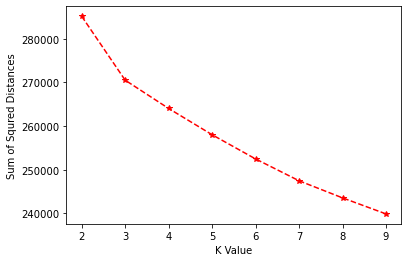

In [14]:
#getting the elbow point for number of clusters
import matplotlib.pyplot as plt
plt.plot(range(2,10), values, '*--',color='red')
plt.xlabel('K Value')
plt.ylabel('Sum of Squred Distances')

In [15]:
kmeans = KMeans(n_clusters=5)             #creating KMeans model instance with 5 clusters
kmeans.fit(data)                          #fitting the data(feature vector data) on the KMeans

KMeans(n_clusters=5)

In [16]:
import pickle

In [17]:
# save the model to disk
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\Kmeans_CL_5_Model.sav'
pickle.dump(kmeans, open(filename, 'wb'))

In [18]:
hist=np.histogram(kmeans.labels_,bins=[0,1,2,3,4,5])

print('histogram of trained kmeans')
print(hist,"\n")

histogram of trained kmeans
(array([130463, 126322,  96851,  88428, 125268], dtype=int64), array([0, 1, 2, 3, 4, 5])) 



Initializing class 0 as dog

In [19]:
#performing kmeans prediction of the entire Dog dataset with the pretrained kmeans model

#initialising i=0; as its the first class
i=0
data=[]
#k=0

for filename in os.listdir(folder1):
    #path
    path=os.path.join(folder1,filename)
    a=cv2.imread(path)
    
    #resize image
    resize=(100, 133)
    img=cv2.resize(a,resize)
    
    #gray image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    sift = cv2.SIFT_create()
    
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    out=pd.DataFrame(normalized)
    
    #predict values of feature vector with pretrained kmeans
    #ValueError: Buffer dtype mismatch, expected 'float', in order to avoid this dtype=np.double
    
    array_double = np.array(out, dtype=np.double)
    a=kmeans.predict(array_double)
    
    hist=np.histogram(a,bins=[0,1,2,3,4,5])
    
    #append the dataframe into the array in append mode, the array will only have 5 values which will store the values in a row
    data.append(hist[0])
    #k=k+1
    
#convert Array to Dataframe and append to the list
Output = pd.DataFrame(data)
#add row class 
Output["Class"] = i 
csv_data=Output.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalDog.csv', mode='a',header=False,index=False)

Initializing class 1 as buffalo

In [20]:
#performing kmeans prediction of the entire Buffalo dataset with the pretrained kmeans model

#initialising i=1; as its the 2nd class
i=1
data=[]
k=0
for filename in os.listdir(folder2):
    path=os.path.join(folder2,filename)
    a=cv2.imread(path)
    resize=(100, 133)
    img=cv2.resize(a,resize)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    out=pd.DataFrame(normalized)
    
    #predict values of feature vector with pretrained kmeans
    #ValueError: Buffer dtype mismatch, expected 'float' but got 'double', in order to avoid this dtype=np.double
    
    array_double = np.array(out, dtype=np.double)
    a=kmeans.predict(array_double)
    hist=np.histogram(a,bins=[0,1,2,3,4,5])
    #append the dataframe into the array in append mode, the array will only have 5 values which will store the values in a row
    data.append(hist[0])
    k=k+1
    
#convert Array to Dataframe and append to the list
Output = pd.DataFrame(data)
#add row class 
Output["Class"] = i 
csv_data = Output.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalBuffalo.csv', mode='a',header=False,index=False)

In [21]:
#performing kmeans prediction of the entire Dog dataset with the pretrained kmeans model

#initialising i=0; as its the first class
i=2
data=[]
k=0

for filename in os.listdir(folder3):
    #path
    path=os.path.join(folder3,filename)
    a=cv2.imread(path)
    
    #resize image
    resize=(100, 133)
    img=cv2.resize(a,resize)
    
    #gray image
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    sift = cv2.SIFT_create()
    
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    out=pd.DataFrame(normalized)
    
    #predict values of feature vector with pretrained kmeans
    #ValueError: Buffer dtype mismatch, expected 'float', in order to avoid this dtype=np.double
    
    array_double = np.array(out, dtype=np.double)
    a=kmeans.predict(array_double)
    
    hist=np.histogram(a,bins=[0,1,2,3,4,5])
    
    #append the dataframe into the array in append mode, the array will only have 5 values which will store the values in a row
    data.append(hist[0])
    k=k+1
    if k > 3500:
        break
    
#convert Array to Dataframe and append to the list
Output = pd.DataFrame(data)
#add row class 
Output["Class"] = i 
csv_data=Output.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalNegative.csv', mode='a',header=False,index=False)

Displaying both the dataframes

In [22]:
#Displaying the kmeans predicted data
print("Dog")
dat1 = pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalDog.csv',header=None)
print(dat1)

Dog
       0   1   2   3   4  5
0     20  41  23  26  49  0
1      5  29  24  17  53  0
2     33  13  12   6  16  0
3     22  35  16   8  29  0
4     33  30  30  22  30  0
...   ..  ..  ..  ..  .. ..
2995  11  21  12  12  16  0
2996  10  17  15   5  18  0
2997   2  15  19  11  18  0
2998  15  18  13  14  22  0
2999  28  37  20  22  24  0

[3000 rows x 6 columns]


In [23]:
print("Buffalo")
dat2 = pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalBuffalo.csv',header=None)
print(dat2)

Buffalo
      0   1   2   3   4  5
0     3  15   8  13   7  1
1     8  10  14  13   2  1
2    34  41  23  27  35  1
3    23  21  18  21  13  1
4    27  31  25  17  21  1
..   ..  ..  ..  ..  .. ..
672  21  26  22  20  22  1
673  26  20   7  11   4  1
674  16  16   3   8  12  1
675  18  16  12  20  11  1
676   6  15   4   7   9  1

[677 rows x 6 columns]


In [24]:
print("Negative")
dat3= pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalNegative.csv',header=None)
print(dat3)

Negative
       0   1   2   3   4  5
0     17   8  13   8  16  2
1     17  11  10   7   8  2
2     28  12   9  12   6  2
3     20  10   5   6   3  2
4     19   8   7   5   5  2
...   ..  ..  ..  ..  .. ..
3496   9   2   6   7   5  2
3497  15   8  15   7  11  2
3498  28  13  21  19  18  2
3499  15   7  10   9   8  2
3500  16   7  14   5  16  2

[3501 rows x 6 columns]


In [25]:
#appending All classes into 1 csv file

A=dat1.append(dat2)
A=A.append(dat3)
csv_data=A.to_csv('D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalFV.csv', mode='a',header=False,index=False)

In [26]:
A

,0,1,2,3,4,5
0,20,41,23,26,49,0
1,5,29,24,17,53,0
2,33,13,12,6,16,0
3,22,35,16,8,29,0
4,33,30,30,22,30,0
...,...,...,...,...,...,...
3496,9,2,6,7,5,2
3497,15,8,15,7,11,2
3498,28,13,21,19,18,2
3499,15,7,10,9,8,2


In [27]:
x = A.iloc[:,0:5].values      #getting the first 5 values of dataframe A into x

In [28]:
x

array([[20, 41, 23, 26, 49],
       [ 5, 29, 24, 17, 53],
       [33, 13, 12,  6, 16],
       ...,
       [28, 13, 21, 19, 18],
       [15,  7, 10,  9,  8],
       [16,  7, 14,  5, 16]], dtype=int64)

In [29]:
y = A.iloc[:,5].values        #getting the last 6th column values in y as target variable
y

array([0, 0, 0, ..., 2, 2, 2], dtype=int64)

In [30]:
from sklearn.preprocessing import StandardScaler      #importing standard scaler to standardize the x(cluster) values to a smaller range
scaler = StandardScaler()
x_transform = scaler.fit_transform(x)

In [31]:
x_transform

array([[ 0.22348096,  1.90008838,  1.20102501,  1.74050837,  2.58037659],
       [-1.61599577,  0.92570613,  1.32737828,  0.59543661,  2.90756448],
       [ 1.81769413, -0.37347021, -0.188861  , -0.80409555, -0.11892355],
       ...,
       [ 1.20453522, -0.37347021,  0.94831846,  0.849897  ,  0.0446704 ],
       [-0.38967795, -0.86066134, -0.44156755, -0.42240496, -0.77329934],
       [-0.26704617, -0.86066134,  0.06384555, -0.93132574, -0.11892355]])

# Using PCA for dimensionality reduction

In [32]:
from sklearn.decomposition import PCA
pca = PCA(n_components=None)            #setting the components to None to generate min(n_samples, n_features) - 1 principal components from the input data
pca.fit(x_transform)

PCA()

In [33]:
xpca = pca.transform(x_transform)
xpca

array([[ 3.7093522 , -0.50759889,  0.48717393,  0.42513388,  0.59617598],
       [ 2.57145405, -2.11707568, -0.49755232,  1.27100823,  1.0398931 ],
       [-0.41779575,  1.89460987,  0.05594986,  0.61012241, -0.0198319 ],
       ...,
       [ 0.92521104,  1.19306679, -0.74151373, -0.60380988,  0.14198784],
       [-1.29983795, -0.11921453, -0.2779015 , -0.28259875,  0.05571764],
       [-0.95889853, -0.05038776, -0.68558879,  0.52990196,  0.15743219]])

In [34]:
xpca = pd.DataFrame(xpca)

In [35]:
xpca

,0,1,2,3,4
0,3.709352,-0.507599,0.487174,0.425134,0.596176
1,2.571454,-2.117076,-0.497552,1.271008,1.039893
2,-0.417796,1.894610,0.055950,0.610122,-0.019832
3,1.127325,0.132876,0.616035,1.260414,-0.503591
4,2.936366,1.422105,-0.682633,-0.023999,-0.354881
...,...,...,...,...,...
7173,-2.118264,-0.727440,-0.236503,-0.355556,0.255293
7174,-0.959699,-0.146700,-0.747689,0.114886,-0.132816
7175,0.925211,1.193067,-0.741514,-0.603810,0.141988
7176,-1.299838,-0.119215,-0.277901,-0.282599,0.055718


In [36]:
xpca.shape

(7178, 5)

In [37]:
print(pca.explained_variance_ratio_)                #getting the percentage of variance explained by components generated by pca

[0.65715681 0.18797186 0.06961345 0.05152115 0.03373675]


In [38]:
pca = PCA(n_components=4)                       #selecting the number of components to explain a 95% of variance
pca.fit(x_transform)

PCA(n_components=4)

In [39]:
# save the model to disk
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\PCA_3_Model.sav'
pickle.dump(kmeans, open(filename, 'wb'))

In [40]:
xpca = pca.transform(x_transform)

In [41]:
xpca

array([[ 3.7093522 , -0.50759889,  0.48717393,  0.42513388],
       [ 2.57145405, -2.11707568, -0.49755232,  1.27100823],
       [-0.41779575,  1.89460987,  0.05594986,  0.61012241],
       ...,
       [ 0.92521104,  1.19306679, -0.74151373, -0.60380988],
       [-1.29983795, -0.11921453, -0.2779015 , -0.28259875],
       [-0.95889853, -0.05038776, -0.68558879,  0.52990196]])

In [42]:
print(pca.explained_variance_ratio_) 

[0.65715681 0.18797186 0.06961345 0.05152115]


In [43]:
xpca = pd.DataFrame(xpca)

In [44]:
xpca

,0,1,2,3
0,3.709352,-0.507599,0.487174,0.425134
1,2.571454,-2.117076,-0.497552,1.271008
2,-0.417796,1.894610,0.055950,0.610122
3,1.127325,0.132876,0.616035,1.260414
4,2.936366,1.422105,-0.682633,-0.023999
...,...,...,...,...
7173,-2.118264,-0.727440,-0.236503,-0.355556
7174,-0.959699,-0.146700,-0.747689,0.114886
7175,0.925211,1.193067,-0.741514,-0.603810
7176,-1.299838,-0.119215,-0.277901,-0.282599


In [45]:
B=pd.concat([xpca, pd.DataFrame(y)],axis=1) #converting the transformed x by pca and y to dataframe and converting it to csv

In [46]:
B

,0,1,2,3,0
0,3.709352,-0.507599,0.487174,0.425134,0
1,2.571454,-2.117076,-0.497552,1.271008,0
2,-0.417796,1.894610,0.055950,0.610122,0
3,1.127325,0.132876,0.616035,1.260414,0
4,2.936366,1.422105,-0.682633,-0.023999,0
...,...,...,...,...,...
7173,-2.118264,-0.727440,-0.236503,-0.355556,2
7174,-0.959699,-0.146700,-0.747689,0.114886,2
7175,0.925211,1.193067,-0.741514,-0.603810,2
7176,-1.299838,-0.119215,-0.277901,-0.282599,2


In [47]:
csv_data=B.to_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalPCAFV.csv', mode='a',header=False,index=False)

In [48]:
data= pd.read_csv(r'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\FinalPCAFV.csv',header=None)
data

,0,1,2,3,4
0,3.709352,-0.507599,0.487174,0.425134,0
1,2.571454,-2.117076,-0.497552,1.271008,0
2,-0.417796,1.894610,0.055950,0.610122,0
3,1.127325,0.132876,0.616035,1.260414,0
4,2.936366,1.422105,-0.682633,-0.023999,0
...,...,...,...,...,...
7173,-2.118264,-0.727440,-0.236503,-0.355556,2
7174,-0.959699,-0.146700,-0.747689,0.114886,2
7175,0.925211,1.193067,-0.741514,-0.603810,2
7176,-1.299838,-0.119215,-0.277901,-0.282599,2


In [49]:
#assigning x the columns from 1 to 128 for training
x = data.iloc[:,0:4].values
print("X values")
print(x)

#assigning y with the column "Class" as target variable
y = data.iloc[:,4]
print("Y values")
print(y)

X values
[[ 3.7093522  -0.50759889  0.48717393  0.42513388]
 [ 2.57145405 -2.11707568 -0.49755232  1.27100823]
 [-0.41779575  1.89460987  0.05594986  0.61012241]
 ...
 [ 0.92521104  1.19306679 -0.74151373 -0.60380988]
 [-1.29983795 -0.11921453 -0.2779015  -0.28259875]
 [-0.95889853 -0.05038776 -0.68558879  0.52990196]]
Y values
0       0
1       0
2       0
3       0
4       0
       ..
7173    2
7174    2
7175    2
7176    2
7177    2
Name: 4, Length: 7178, dtype: int64


# Dataset splitting for train and test purposes

In [50]:
#Dataset split into train and test with 80% Training and 20% Testing
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=0)

# SVM-ovr

### Linear kernel

In [51]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovr_k1 = SVC(kernel='linear',decision_function_shape='ovr')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovr_k1.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovr_k1.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovr_k1 = model_SVMovr_k1.predict(x_test)
#Results
print("SVM-ovr kernel1 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovr_k1.predict(x_train))*100,"%")
print("SVM-ovr kernel1 Accuracy: ",accuracy_score(y_test, y_predSVMovr_k1)*100,"%")

SVM-ovr kernel1 Results
Training accuracy:  79.95471960989202 %
SVM-ovr kernel1 Accuracy:  80.50139275766016 %


In [52]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovr_k1)

array([[485,  11, 106],
       [ 33,  37,  50],
       [ 67,  13, 634]], dtype=int64)

#### Precision, Recall, F1-score

In [53]:
print("Precision: ", precision_score(y_test, y_predSVMovr_k1, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovr_k1, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovr_k1).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovr_k1, average = 'macro'))

Precision:  0.7460496172262099
Recall/Sensitivity:  0.667312118645908
F1-score:  0.6897036896815933


### Polynomial kernel

In [54]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovr_k2 = SVC(kernel='poly',decision_function_shape='ovr')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovr_k2.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovr_k2.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovr_k2 = model_SVMovr_k2.predict(x_test)
#Results
print("SVM-ovr kernel2 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovr_k2.predict(x_train))*100,"%")
print("SVM-ovr kernel2 Accuracy: ",accuracy_score(y_test, y_predSVMovr_k2)*100,"%")

SVM-ovr kernel2 Results
Training accuracy:  78.47439916405433 %
SVM-ovr kernel2 Accuracy:  79.80501392757661 %


In [55]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovr_k2)

array([[432,   6, 164],
       [ 23,  37,  60],
       [ 29,   8, 677]], dtype=int64)

#### Precision, Recall, F1-score

In [56]:
print("Precision: ", precision_score(y_test, y_predSVMovr_k2, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovr_k2, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovr_k2).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovr_k2, average = 'macro'))

Precision:  0.7898131756470975
Recall/Sensitivity:  0.6580401928213145
F1-score:  0.6889062471293969


### RBF kernel

In [57]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovr_k3 = SVC(kernel='rbf',decision_function_shape='ovr')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovr_k3.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovr_k3.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovr_k3 = model_SVMovr_k3.predict(x_test)
#Results
print("SVM-ovr kernel3 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovr_k3.predict(x_train))*100,"%")
print("SVM-ovr kernel3 Accuracy: ",accuracy_score(y_test, y_predSVMovr_k3)*100,"%")

SVM-ovr kernel3 Results
Training accuracy:  81.10414489724835 %
SVM-ovr kernel3 Accuracy:  81.19777158774373 %


In [58]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovr_k3)

array([[498,  11,  93],
       [ 37,  43,  40],
       [ 71,  18, 625]], dtype=int64)

#### Precision, Recall, F1-score

In [59]:
print("Precision: ", precision_score(y_test, y_predSVMovr_k3, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovr_k3, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovr_k3).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovr_k3, average = 'macro'))

Precision:  0.7478475530050807
Recall/Sensitivity:  0.6869753327687663
F1-score:  0.7072015868445468


# SVM-ovo

### Linear kernel

In [60]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovo_k1 = SVC(kernel='linear',decision_function_shape='ovo')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovo_k1.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovo_k1.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovo_k1 = model_SVMovo_k1.predict(x_test)
#Results
print("SVM-ovo kernel1 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovo_k1.predict(x_train))*100,"%")
print("SVM-ovo kernel1 Accuracy: ",accuracy_score(y_test, y_predSVMovo_k1)*100,"%")

SVM-ovo kernel1 Results
Training accuracy:  79.95471960989202 %
SVM-ovo kernel1 Accuracy:  80.50139275766016 %


In [61]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovo_k1)

array([[485,  11, 106],
       [ 33,  37,  50],
       [ 67,  13, 634]], dtype=int64)

#### Precision, Recall, F1-score

In [62]:
print("Precision: ", precision_score(y_test, y_predSVMovo_k1, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovo_k1, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovo_k1).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovo_k1, average = 'macro'))

Precision:  0.7460496172262099
Recall/Sensitivity:  0.667312118645908
F1-score:  0.6897036896815933


### Polnomial kernel

In [63]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovo_k2 = SVC(kernel='poly',decision_function_shape='ovo')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovo_k2.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovo_k2.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovo_k2 = model_SVMovo_k2.predict(x_test)
#Results
print("SVM-ovo kernel2 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovo_k2.predict(x_train))*100,"%")
print("SVM-ovo kernel2 Accuracy: ",accuracy_score(y_test, y_predSVMovo_k2)*100,"%")

SVM-ovo kernel2 Results
Training accuracy:  78.47439916405433 %
SVM-ovo kernel2 Accuracy:  79.80501392757661 %


In [64]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovo_k2)

array([[432,   6, 164],
       [ 23,  37,  60],
       [ 29,   8, 677]], dtype=int64)

#### Precision, Recall, F1-score

In [65]:
print("Precision: ", precision_score(y_test, y_predSVMovo_k2, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovo_k2, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovo_k2).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovo_k2, average = 'macro'))

Precision:  0.7898131756470975
Recall/Sensitivity:  0.6580401928213145
F1-score:  0.6889062471293969


### RBF kernel

In [66]:
#SVM Classifier
#Assign model with SVM classifier
model_SVMovo_k3 = SVC(kernel='rbf',decision_function_shape='ovo')
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelSVMovo_k3.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_SVMovo_k3.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predSVMovo_k3 = model_SVMovo_k3.predict(x_test)
#Results
print("SVM-ovo kernel3 Results")
print("Training accuracy: ", accuracy_score(y_train, model_SVMovo_k3.predict(x_train))*100,"%")
print("SVM-ovo kernel3 Accuracy: ",accuracy_score(y_test, y_predSVMovo_k3)*100,"%")

SVM-ovo kernel3 Results
Training accuracy:  81.10414489724835 %
SVM-ovo kernel3 Accuracy:  81.19777158774373 %


In [67]:
#confusion matrix
confusion_matrix(y_test, y_predSVMovo_k3)

array([[498,  11,  93],
       [ 37,  43,  40],
       [ 71,  18, 625]], dtype=int64)

#### Precision, Recall, F1-score

In [68]:
print("Precision: ", precision_score(y_test, y_predSVMovo_k3, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predSVMovo_k3, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predSVMovo_k3).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predSVMovo_k3, average = 'macro'))

Precision:  0.7478475530050807
Recall/Sensitivity:  0.6869753327687663
F1-score:  0.7072015868445468


# KNN

In [69]:
#KNN Classifier
#Assign model with KNN classifier
model_KNN = KNeighborsClassifier()
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelKNN.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_KNN.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predKNN = model_KNN.predict(x_test)
#Results
print("KNN Results")
print("Training accuracy: ", accuracy_score(y_train, model_KNN.predict(x_train))*100,"%")
print("KNN Accuracy: ",accuracy_score(y_test, y_predKNN)*100,"%")

KNN Results
Training accuracy:  85.17938000696621 %
KNN Accuracy:  79.10863509749304 %


In [70]:
#confusion matrix
confusion_matrix(y_test, y_predKNN)

array([[500,  19,  83],
       [ 41,  51,  28],
       [ 94,  35, 585]], dtype=int64)

#### Precision, Recall, F1-score

In [71]:
print("Precision: ", precision_score(y_test, y_predKNN, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predKNN, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predKNN).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predKNN, average = 'macro'))

Precision:  0.7045443672989152
Recall/Sensitivity:  0.6916308383818643
F1-score:  0.6971760015747702


# Decision Tree

In [72]:
#Decision Tree Classifier
#Assign model with Decision Tree classifier
model_DT = DecisionTreeClassifier(max_depth=6, max_leaf_nodes=4)
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelDT.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_DT.fit(x_train, y_train)
#predicting the target variable using testing variables
y_predDT = model_DT.predict(x_test)
#Results
print("Decision Tree Results")
print("Training accuracy: ", accuracy_score(y_train, model_DT.predict(x_train))*100,"%")
print("Decision Tree Accuracy: ",accuracy_score(y_test, y_predDT)*100,"%")

Decision Tree Results
Training accuracy:  74.95646116335772 %
Decision Tree Accuracy:  76.88022284122563 %


In [73]:
#confusion matrix
confusion_matrix(y_test, y_predDT)

array([[458,   0, 144],
       [ 20,   0, 100],
       [ 68,   0, 646]], dtype=int64)

#### Precision, Recall, F1-score

In [74]:
print("Precision: ", precision_score(y_test, y_predDT, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predDT, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predDT).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predDT, average = 'macro'))

Precision:  0.5215568451523508
Recall/Sensitivity:  0.5551864156515319
F1-score:  0.5344652306515941


C:\Users\Pranav\Anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


# Random Forest

In [75]:
#Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
#Assign model with Decision Tree classifier
model_RF = RandomForestClassifier(n_estimators=1000, criterion='gini', max_depth=None, min_samples_split=4,
                                min_samples_leaf=3, min_weight_fraction_leaf=0.0, max_features='auto',
                                max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, 
                                n_jobs=None, random_state=2, verbose=0, warm_start=False, class_weight=None, 
                                ccp_alpha=0.0, max_samples=None)
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\model4.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_RF.fit(x_train, y_train)
#predicting the traget variable using testing variables
y_predRF = model_RF.predict(x_test)
#Results
print("RandomF Results")
print("Training accuracy: ", accuracy_score(y_train, model_RF.predict(x_train))*100,"%")
print("RandomF Accuracy: ",accuracy_score(y_test, y_predRF)*100,"%")

RandomF Results
Training accuracy:  93.17311041448973 %
RandomF Accuracy:  82.24233983286908 %


In [76]:
#confusion matrix
confusion_matrix(y_test, y_predRF)

array([[505,  15,  82],
       [ 40,  48,  32],
       [ 63,  23, 628]], dtype=int64)

#### Precision, Recall, F1-score

In [77]:
print("Precision: ", precision_score(y_test, y_predRF, average = 'macro'))
print("Recall/Sensitivity: ",recall_score(y_test, y_predRF, average = 'macro'))
#tn, fp, fn, tp = confusion_matrix(y_test, y_predRF).ravel()
#specificity = tn / (tn+fp)
#print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predRF, average = 'macro'))

Precision:  0.7450309420435688
Recall/Sensitivity:  0.7061407508739931
F1-score:  0.7211225079715812


# Logistic Regression not needed

In [ ]:
from sklearn.linear_model import LogisticRegression
model_LR = LogisticRegression()
filename = 'D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\CSV\modelLR.sav'
pickle.dump(kmeans, open(filename, 'wb'))
#training the model with the Training Variables 
model_LR.fit(x_train, y_train)
#predicting the traget variable using testing variables
y_predLR = model_LR.predict(x_test)
#Results
print("Logistic Regression Results")
print("Training accuracy: ", accuracy_score(y_train, model_LR.predict(x_train))*100,"%")
print("Logistic Regression Accuracy: ",accuracy_score(y_test, y_predLR)*100,"%")

In [ ]:
#confusion matrix
confusion_matrix(y_test, y_predLR)

#### Precision, Recall, F1-score

In [ ]:
print("Precision: ", precision_score(y_test, y_predLR))
print("Recall/Sensitivity: ",recall_score(y_test, y_predLR))
tn, fp, fn, tp = confusion_matrix(y_test, y_predLR).ravel()
specificity = tn / (tn+fp)
print("Specificity: ", specificity)
print("F1-score: ",f1_score(y_test, y_predLR))

# Prediction

### Single Image

In [108]:
test = []
path = r"D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\Buffalo_Final\No_BG\P120.jpg"

#Repeated the process of image pre-processing and feature extraction
img=cv2.imread(path)
resize=(100, 133)

#resize image
img=cv2.resize(img,resize)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

#initialise sift descriptor
sift = cv2.SIFT_create()
keypoints, descriptors = sift.detectAndCompute(gray, None)
norm = Normalizer()
normalized = norm.fit_transform(descriptors)
#convert the descriptor array into a dataframe format
out=pd.DataFrame(normalized)
print("descriptor shape ",i," : ", out.shape)

#train the model for the features i.e. for all elements in the Dataframe
array_double = np.array(out, dtype=np.double)
a = kmeans.predict(array_double)

#get the values of the histogram for one image only for 5 clusters i.e. in 5 bins
#kmeans.labels_ give us the label vlaue of the feature that its clustered into
#hist will give the histogram for all those vlaues
hist = np.histogram(a,bins=[0,1,2,3,4,5])

#append the dataframe into the array in append mode, the array will only have 5 values which will store the values in a row
test.append(hist[0])
print(test)

Output = pd.DataFrame(test)
print("Histogram:\n",Output)
Output_trans = scaler.transform(Output)
print(Output_trans.shape, Output_trans)
pcaOutput = pca.transform(Output_trans)
print(pcaOutput.shape, pcaOutput)
print(model_SVMovr_k1.predict(pcaOutput))
print(model_SVMovr_k2.predict(pcaOutput))
print(model_SVMovr_k3.predict(pcaOutput))
print(model_SVMovo_k1.predict(pcaOutput))
print(model_SVMovo_k2.predict(pcaOutput))
print(model_SVMovo_k3.predict(pcaOutput))
print(model_KNN.predict(pcaOutput))
print(model_DT.predict(pcaOutput))
print(model_RF.predict(pcaOutput))
#print(model_LR.predict(pcaOutput))

descriptor shape  100  :  (45, 128)
[array([ 7, 14,  9,  7,  8], dtype=int64)]
Histogram:
    0   1  2  3  4
0  7  14  9  7  8
(1, 5) [[-1.37073221 -0.29227169 -0.56792082 -0.67686535 -0.77329934]]
(1, 4) [[-1.37861921 -1.16055695  0.01256467 -0.03751956]]
[2]
[2]
[2]
[2]
[2]
[2]
[1]
[2]
[1]


# Multiple Image Prediction

In [79]:
foldertest = r"D:\Third Year\Fifth Sem\Computer Vision\Lab\CP\Test"
i=0
test = []
for filename in os.listdir(foldertest):
    #path
    path=os.path.join(foldertest,filename)
    img=cv2.imread(path)
    resize=(100, 133)

    #resize image
    img=cv2.resize(img,resize)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    #initialise sift descriptor
    sift = cv2.SIFT_create()
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    norm = Normalizer()
    normalized = norm.fit_transform(descriptors)
    #convert the descriptor array into a dataframe format
    out=pd.DataFrame(normalized)
    print("descriptor shape ",i," : ", out.shape)

    #train the model for the features i.e. for all elements in the Dataframe
    array_double = np.array(out, dtype=np.double)
    a = kmeans.predict(array_double)

    #get the values of the histogram for one image only for 5 clusters i.e. in 5 bins
    #kmeans.labels_ give us the label vlaue of the feature that its clustered into
    #hist will give the histogram for all those vlaues
    hist = np.histogram(a,bins=[0,1,2,3,4,5])

    #append the dataframe into the array in append mode, the array will only have 5 values which will store the values in a row
    test.append(hist[0])
    i=i+1

Output = pd.DataFrame(test)
#print("Histogram:\n",Output)
Output_trans = scaler.transform(Output)
#print(Output_trans.shape, Output_trans)
pcaOutput = pca.transform(Output_trans)
#print(pcaOutput.shape, pcaOutput)
model_RF.predict(pcaOutput)

descriptor shape  0  :  (117, 128)
descriptor shape  1  :  (96, 128)
descriptor shape  2  :  (146, 128)
descriptor shape  3  :  (137, 128)
descriptor shape  4  :  (152, 128)
descriptor shape  5  :  (79, 128)
descriptor shape  6  :  (48, 128)
descriptor shape  7  :  (57, 128)
descriptor shape  8  :  (115, 128)
descriptor shape  9  :  (98, 128)
descriptor shape  10  :  (108, 128)
descriptor shape  11  :  (107, 128)
descriptor shape  12  :  (123, 128)
descriptor shape  13  :  (110, 128)
descriptor shape  14  :  (143, 128)
descriptor shape  15  :  (74, 128)
descriptor shape  16  :  (86, 128)
descriptor shape  17  :  (74, 128)
descriptor shape  18  :  (59, 128)
descriptor shape  19  :  (134, 128)
descriptor shape  20  :  (164, 128)
descriptor shape  21  :  (86, 128)
descriptor shape  22  :  (88, 128)
descriptor shape  23  :  (155, 128)
descriptor shape  24  :  (152, 128)
descriptor shape  25  :  (108, 128)
descriptor shape  26  :  (96, 128)
descriptor shape  27  :  (136, 128)
descriptor sha

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 1, 1, 1, 1, 0, 1, 2, 2], dtype=int64)